# Build One Brain Graph

Construct a PyTorch Geometric graph for one participant using CC200 functional connectivity and temporal-spatial node features.


## Import data and tools


In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", message="IProgress not found.*")

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
from nilearn import datasets
from nilearn.plotting import find_parcellation_cut_coords
from torch import nn
from torch_geometric.data import Data


## Load one preprocessed ABIDE participant


In [2]:
N_SUBJECTS = 1
PROJECT_ROOT = Path.cwd().parent
ABIDE_DATA_DIR = PROJECT_ROOT / "data" / "abide_pcp"

abide = datasets.fetch_abide_pcp(
    data_dir=ABIDE_DATA_DIR,
    n_subjects=N_SUBJECTS,
    pipeline="cpac",
    band_pass_filtering=True,
    global_signal_regression=False,
    derivatives=["rois_cc200"],
    quality_checked=True,
    verbose=0,
)
print(
    "[fetch_abide_pcp] Dataset directory found: "
    f"{ABIDE_DATA_DIR.relative_to(PROJECT_ROOT) / 'ABIDE_pcp'}"
)

phenotypic = abide.phenotypic
cc200_time_series = abide.rois_cc200


[fetch_abide_pcp] Dataset directory found: data\abide_pcp\ABIDE_pcp


## Select the participant


In [3]:
participant = phenotypic.iloc[0]
roi_time_series = cc200_time_series[0]

print(f"Participant: {participant['FILE_ID']}")
print(f"ROI time-series shape: {roi_time_series.shape}")
print(f"DX_GROUP: {participant['DX_GROUP']}")


Participant: Pitt_0050003
ROI time-series shape: (196, 200)
DX_GROUP: 1


## Build the Pearson correlation matrix


In [4]:
correlation_matrix = np.corrcoef(roi_time_series, rowvar=False)
correlation_matrix.shape


(200, 200)

## Build the connectivity matrix

Retain correlations with `|r| >= 0.5` and remove self-connections.


In [5]:
THRESHOLD = 0.5

connectivity_matrix = correlation_matrix.copy()
connectivity_matrix[np.abs(connectivity_matrix) < THRESHOLD] = 0
np.fill_diagonal(connectivity_matrix, 0)

connectivity_matrix.shape


(200, 200)

## Visualize the matrices


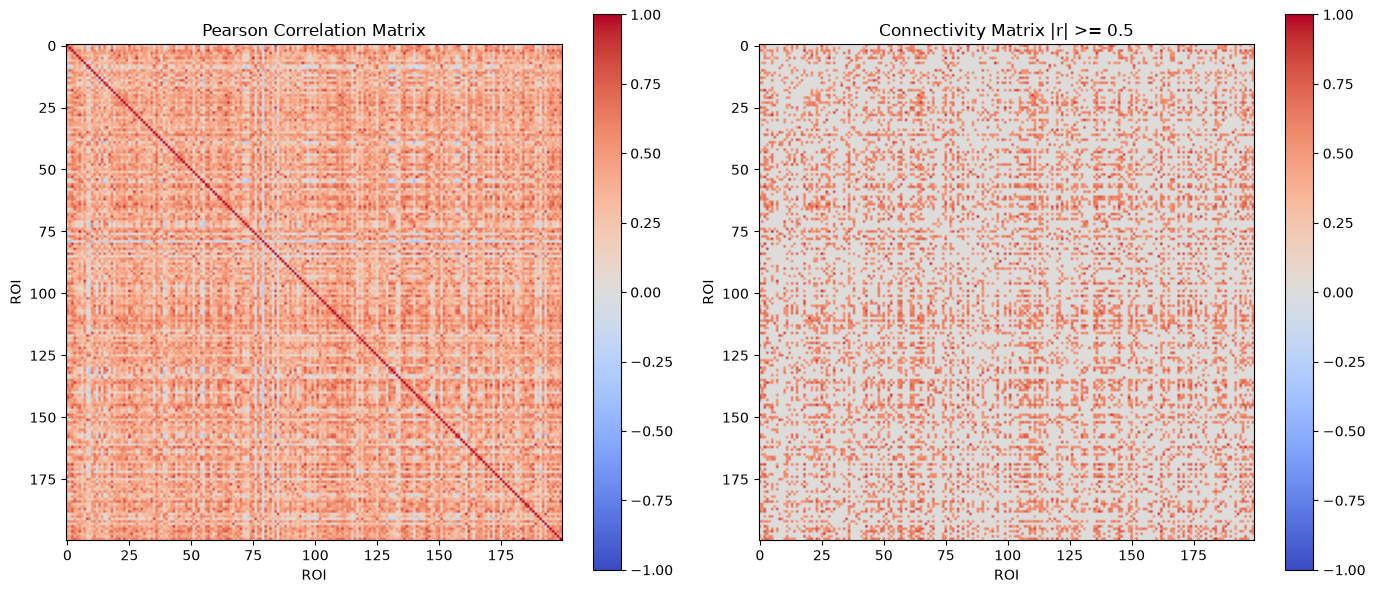

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

correlation_plot = axes[0].imshow(
    correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1
)
axes[0].set_title("Pearson Correlation Matrix")
axes[0].set_xlabel("ROI")
axes[0].set_ylabel("ROI")
fig.colorbar(correlation_plot, ax=axes[0])

connectivity_plot = axes[1].imshow(
    connectivity_matrix, cmap="coolwarm", vmin=-1, vmax=1
)
axes[1].set_title("Connectivity Matrix |r| >= 0.5")
axes[1].set_xlabel("ROI")
axes[1].set_ylabel("ROI")
fig.colorbar(connectivity_plot, ax=axes[1])

plt.tight_layout()
plt.show()


## Create node features

- Shared 1D CNN for all 200 ROIs
- Output per ROI: 32-dimensional embedding
- Current CNN weights: untrained


In [7]:
class ROIEncoder(nn.Module):
    def __init__(self, embedding_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1),
            nn.Flatten(),
            nn.Linear(32, embedding_dim),
        )

    def forward(self, x):
        return self.encoder(x)


### Prepare the ROI time series and run the CNN

- Time series: `[196, 200]`
- CNN input: `[200, 1, 196]`
- CNN output: `[200, 32]`


In [8]:
cnn_input = torch.tensor(roi_time_series.T, dtype=torch.float).unsqueeze(1)

torch.manual_seed(42)
roi_encoder = ROIEncoder(embedding_dim=32)
node_embeddings = roi_encoder(cnn_input)

print(f"CNN input shape: {cnn_input.shape}")
print(f"Embedding shape: {node_embeddings.shape}")


CNN input shape: torch.Size([200, 1, 196])
Embedding shape: torch.Size([200, 32])


### Load and normalize the CC200 ROI coordinates

- Centroid coordinates: `[200, 3]`
- Verify atlas labels `1–200`
- Standardize each coordinate axis


In [9]:
CC200_ATLAS_PATH = PROJECT_ROOT / "data" / "atlases" / "cc200_roi_atlas.nii.gz"

roi_coordinates, roi_labels = find_parcellation_cut_coords(
    CC200_ATLAS_PATH,
    background_label=0,
    return_label_names=True,
)
roi_labels = np.asarray(roi_labels, dtype=int)
expected_labels = np.arange(1, roi_time_series.shape[1] + 1)

assert np.array_equal(roi_labels, expected_labels)
assert roi_coordinates.shape == (roi_time_series.shape[1], 3)

roi_coordinates = torch.tensor(roi_coordinates, dtype=torch.float)
coordinate_mean = roi_coordinates.mean(dim=0, keepdim=True)
coordinate_std = roi_coordinates.std(dim=0, unbiased=False, keepdim=True)
normalized_coordinates = (roi_coordinates - coordinate_mean) / coordinate_std

print(f"Coordinate shape: {roi_coordinates.shape}")
print(f"Atlas labels: {roi_labels[0]} to {roi_labels[-1]}")
print(f"Normalized coordinate means: {normalized_coordinates.mean(dim=0)}")
print(
    "Normalized coordinate standard deviations: "
    f"{normalized_coordinates.std(dim=0, unbiased=False)}"
)


Coordinate shape: torch.Size([200, 3])
Atlas labels: 1 to 200
Normalized coordinate means: tensor([ 0.0000e+00, -2.7418e-08,  4.7684e-09])
Normalized coordinate standard deviations: tensor([1., 1., 1.])


## Build the graph

- CNN embedding: 32 features
- Spatial coordinates: 3 features
- Final node features: 35
- Graph label: `0 = Control`, `1 = ASD`


In [10]:
node_features = torch.cat(
    (node_embeddings, normalized_coordinates),
    dim=1,
)
print(f"Node-feature shape: {node_features.shape}")

dx_group_to_label = {1: 1, 2: 0}
dx_group = int(participant["DX_GROUP"])

if dx_group not in dx_group_to_label:
    raise ValueError(f"Unexpected DX_GROUP value: {dx_group}")

label = dx_group_to_label[dx_group]
graph_label = torch.tensor([label], dtype=torch.long)

source_nodes, target_nodes = np.nonzero(connectivity_matrix)

edge_index = torch.tensor(
    np.vstack((source_nodes, target_nodes)), dtype=torch.long
)
edge_attr = torch.tensor(
    connectivity_matrix[source_nodes, target_nodes], dtype=torch.float
).unsqueeze(1)

graph = Data(
    x=node_features,
    edge_index=edge_index,
    edge_attr=edge_attr,
    y=graph_label,
)

graph

Node-feature shape: torch.Size([200, 35])


Data(x=[200, 35], edge_index=[2, 11150], edge_attr=[11150, 1], y=[1])

In [11]:
print(f"Number of nodes: {graph.x.shape[0]}")
print(f"Node feature dimension: {graph.x.shape[1]}")
print(f"Number of edges: {graph.edge_index.shape[1]}")
print(f"Edge attribute shape: {graph.edge_attr.shape}")
print(f"Graph label: {graph.y.item()}")
print(f"\nFirst 5 node features:\n{graph.x[:5]}")
print(f"\nFirst 5 edges:\n{graph.edge_index[:, :5]}")
print(f"\nFirst 5 edge attributes:\n{graph.edge_attr[:5]}")

Number of nodes: 200
Node feature dimension: 35
Number of edges: 11150
Edge attribute shape: torch.Size([11150, 1])
Graph label: 1

First 5 node features:
tensor([[ -12.0548,   10.7665,  -19.5529,  -54.3277,   50.6997,  -15.5537,
          -91.1644,  -12.5082,    4.3036,    8.4652,   23.7693,   56.9812,
           15.6942,    3.6433,  -42.5569,  -41.7332,   -9.6378,   13.9914,
          -22.8303,  -50.1887,  -38.1809,   17.9485,  -23.7799,   60.5245,
           23.1993,  -72.0194,    8.6302,  -70.4475,  -21.0266,   -3.1531,
           -2.7629,   10.7124,   -1.1517,   -1.6052,   -0.3649],
        [   3.2564,    7.7023,   -6.8163,  -34.9970,   27.1263,  -10.5989,
          -52.1091,   -0.5068,   -1.0465,    0.9164,    8.8145,   26.7582,
            5.8471,    7.1138,  -24.9436,  -24.6467,   -0.4647,    6.0222,
          -11.0212,  -24.1176,  -16.3193,    9.1302,  -16.0692,   37.6529,
           10.1342,  -44.6243,    7.7587,  -42.6773,   -6.2750,   -2.3545,
           -8.3066,    2.8973,

## Visualize the graph


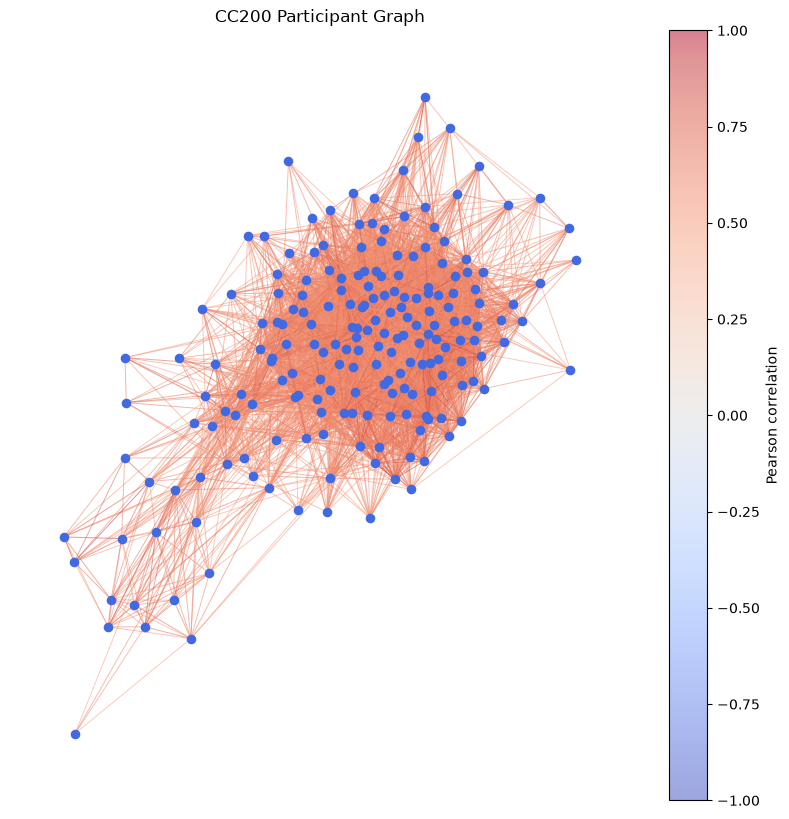

In [12]:
brain_graph = nx.from_numpy_array(connectivity_matrix)
positions = nx.spring_layout(brain_graph, seed=42, weight=None)
edge_colors = [brain_graph[u][v]["weight"] for u, v in brain_graph.edges]

fig, ax = plt.subplots(figsize=(10, 10))
nx.draw_networkx_nodes(
    brain_graph, positions, node_size=35, node_color="royalblue", ax=ax
)
edges = nx.draw_networkx_edges(
    brain_graph,
    positions,
    edge_color=edge_colors,
    edge_cmap=plt.cm.coolwarm,
    edge_vmin=-1,
    edge_vmax=1,
    width=0.7,
    alpha=0.5,
    ax=ax,
)
fig.colorbar(edges, ax=ax, label="Pearson correlation")
ax.set_title("CC200 Participant Graph")
ax.axis("off")
plt.show()